In [40]:
import pandas as pd
import numpy as np
import sklearn as skl
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport


In [32]:
# using a dataset from kaggle that tracked the user rankings for each ai model since they became publicly available
df = pd.read_csv(r"C:\Users\perry\First-Data-Science-Project\ai_model_arena_rankings.csv.csv")

df.head()

,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
0,vicuna-13b,LMSYS,Llama 2 Community,1094.0,NaN,NaN,NaN,NaN,1.0,overall,2023-05-08,text
1,koala-13b,UC Berkeley,Non-commercial,1015.0,NaN,NaN,NaN,NaN,2.0,overall,2023-05-08,text
2,RWKV-4-Raven-14B,RWKV,Apache 2.0,979.0,NaN,NaN,NaN,NaN,3.0,overall,2023-05-08,text
3,oasst-pythia-12b,OpenAssistant,Apache 2.0,941.0,NaN,NaN,NaN,NaN,4.0,overall,2023-05-08,text
4,alpaca-13b,Stanford,Non-commercial,935.0,NaN,NaN,NaN,NaN,5.0,overall,2023-05-08,text


In [ ]:
df.describe

<bound method NDFrame.describe of                  model_name   organization            license       rating  \
0                vicuna-13b          LMSYS  Llama 2 Community  1094.000000   
1                 koala-13b    UC Berkeley     Non-commercial  1015.000000   
2          RWKV-4-Raven-14B           RWKV         Apache 2.0   979.000000   
3          oasst-pythia-12b  OpenAssistant         Apache 2.0   941.000000   
4                alpaca-13b       Stanford     Non-commercial   935.000000   
...                     ...            ...                ...          ...   
97372          gpt-5-search         openai        Proprietary  1132.337817   
97373    ppl-sonar-pro-high     Perplexity        Proprietary  1129.385404   
97374  claude-opus-4-search      anthropic        Proprietary  1126.476734   
97375      diffbot-small-xl        diffbot         Apache 2.0  1022.913853   
97376     api-gpt-4o-search         openai        Proprietary  1006.215621   

       rating_lower  rating_u

In [33]:
# determining how many values in each column are null, if any --> we will need to impute so model does not break or bias
df.isnull().sum()

model_name                     0
organization                3477
license                      131
rating                         0
rating_lower                 307
rating_upper                 307
variance                     307
vote_count                   307
rank                           0
category                       0
leaderboard_publish_date       0
subset                         0
dtype: int64

In [34]:
# now that we have the null counts for each column, put these columns into numerical or categorical buckets

num_variables = df.select_dtypes(include = ['number']).columns
cat_variables = df.select_dtypes(include = ['object', 'category']).columns

print(num_variables)
print(cat_variables)

Index(['rating', 'rating_lower', 'rating_upper', 'variance', 'vote_count',
       'rank'],
      dtype='object')
Index(['model_name', 'organization', 'license', 'category',
       'leaderboard_publish_date', 'subset'],
      dtype='object')


In [35]:
# for categorical variables, we can impute null values with the mode

for col in cat_variables:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
    
    
df.isnull().sum()

model_name                    0
organization                  0
license                       0
rating                        0
rating_lower                307
rating_upper                307
variance                    307
vote_count                  307
rank                          0
category                      0
leaderboard_publish_date      0
subset                        0
dtype: int64

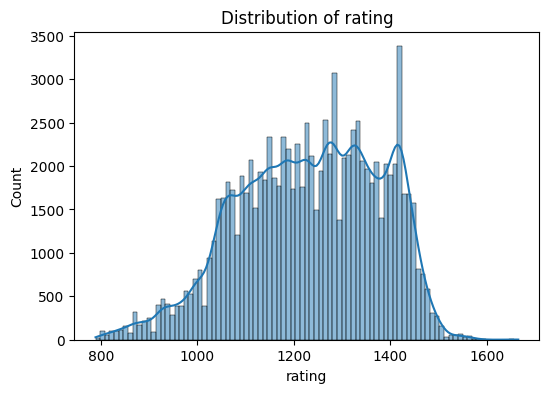

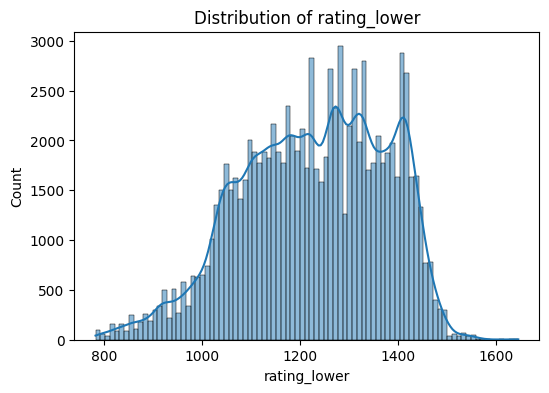

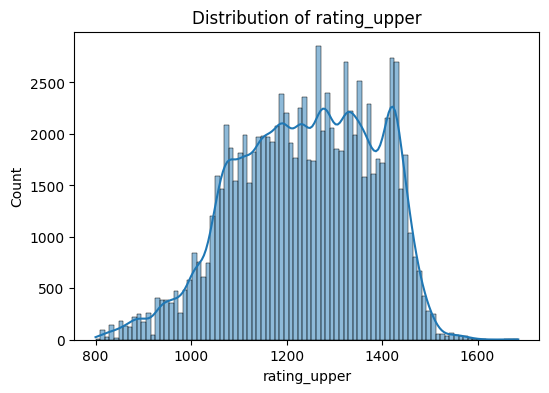

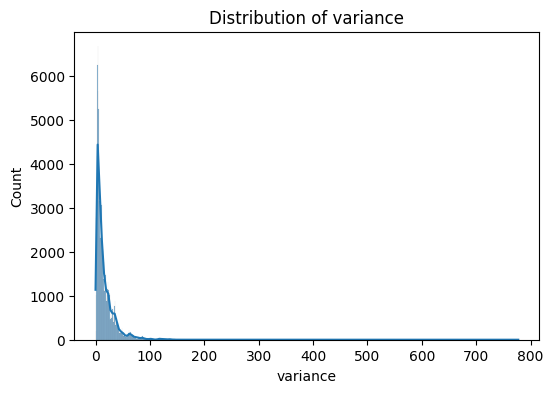

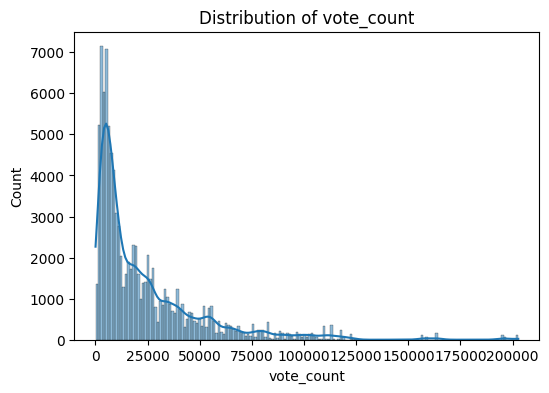

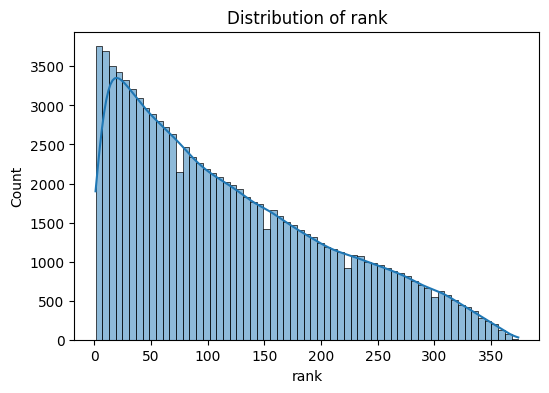

In [26]:
# before deciding whether to impute the mean or the median for the numerical columns, we want to check the distribution shape of each column

for col in num_variables:
    # always start charts with figure size
    plt.figure(figsize = (6, 4))
    # pick the chart you want to use, using seaborn histplot for this
    sns.histplot(df[col], kde = True)
    # title of the chart
    plt.title(f'Distribution of {col}')
    plt.show()

In [36]:
# since the skewness of each numerical variable is different, we can implement a loop to check for skewness and then impute median vs mode based on that

for col in num_variables:
    skewness = df[col].skew()
    if abs(skewness) > 0.5:
        fill_value = df[col].median()
    else:
        fill_value = df[col].mean()
    df[col] = df[col].fillna(fill_value)

In [37]:
# check again for null values
df.isnull().sum()

model_name                  0
organization                0
license                     0
rating                      0
rating_lower                0
rating_upper                0
variance                    0
vote_count                  0
rank                        0
category                    0
leaderboard_publish_date    0
subset                      0
dtype: int64

In [41]:
# now that we have no more null values, we can do EDA
profile = ProfileReport(df, title='AI Model Rating EDA')
profile.to_file('eda_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 110.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
df.groupby('subset')[['rating', 'rank']].corr()

# or even more precise, within each subset AND date
df.groupby(['subset', 'leaderboard_publish_date'])[['rating', 'rank']].corr()

rating      rank
subset leaderboard_publish_date                           
search 2025-08-07               rating  1.000000 -0.901260
                                rank   -0.901260  1.000000
       2025-08-14               rating  1.000000 -0.855015
                                rank   -0.855015  1.000000
       2025-08-18               rating  1.000000 -0.859115
...                                          ...       ...
webdev 2026-07-02               rank   -0.978286  1.000000
       2026-07-09               rating  1.000000 -0.977804
                                rank   -0.977804  1.000000
       2026-07-10               rating  1.000000 -0.978243
                                rank   -0.978243  1.000000

[1242 rows x 2 columns]

## Modeling: predicting `rating`

We'll train four regressors to predict a model's Arena `rating` from its metadata: a **Decision Tree**, a **Random Forest**, **XGBoost**, and a **Linear Regression** baseline 

`rating_lower`, `rating_upper`, `variance`, and `rank` are all dropped as features — they're computed directly from `rating`, so keeping them would leak the target.

In [49]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [50]:
model_df = df.drop(columns=['rating_lower', 'rating_upper', 'variance', 'rank'])

# turn the publish date into numeric features a model can actually use
model_df['leaderboard_publish_date'] = pd.to_datetime(model_df['leaderboard_publish_date'])
model_df['publish_year'] = model_df['leaderboard_publish_date'].dt.year
model_df['publish_month'] = model_df['leaderboard_publish_date'].dt.month
model_df = model_df.drop(columns=['leaderboard_publish_date'])

cat_cols = ['organization', 'license', 'category', 'subset']

# tree-based models handle ordinal-encoded categories fine, and it avoids a huge
# one-hot matrix from a high-cardinality column like `organization`
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
model_df[cat_cols] = encoder.fit_transform(model_df[cat_cols])

groups = model_df['model_name']
X = model_df.drop(columns=['rating', 'model_name'])
y = model_df['rating']

# GroupShuffleSplit keeps every row for a given model_name entirely in train OR entirely
# in test -- a plain train_test_split would let the same model 'leak' across both,
# which is what was inflating Random Forest's R2 earlier.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# sanity check: this should print 0 -- no model_name should appear in both sets
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print('models appearing in both train and test:', len(overlap))

X_train.shape, X_test.shape

models appearing in both train and test: 0


((77895, 7), (19482, 7))

In [51]:
models = {
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    'Linear Regression': LinearRegression(),
}


In [52]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,XGBoost,58.910154,75.534850,0.688556
1,Random Forest,70.654586,94.380787,0.513759
2,Decision Tree,77.374353,100.441800,0.449302
3,Linear Regression,96.537371,118.057946,0.239192


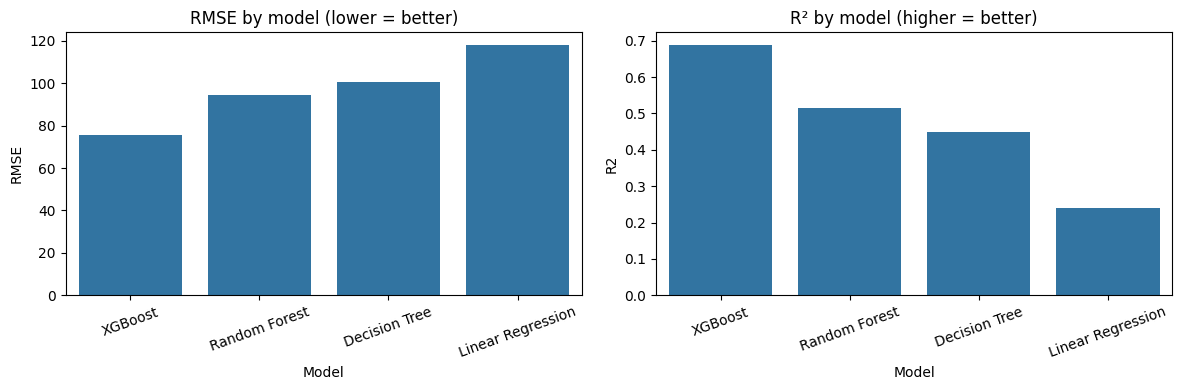

In [53]:
# --- Compare model performance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE by model (lower = better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2', ax=axes[1])
axes[1].set_title('R² by model (higher = better)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


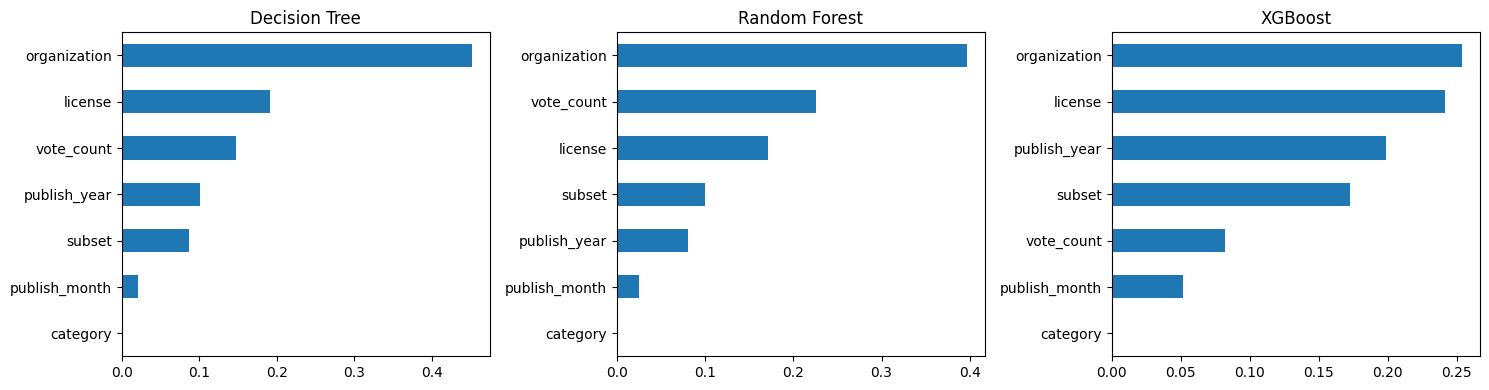

In [54]:
# --- Feature importance (tree-based models only) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, ['Decision Tree', 'Random Forest', 'XGBoost']):
    importances = pd.Series(fitted_models[name].feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()